# W2D5 — Train, Validate and Evaluate — Lab

**Week 2 · Day 5 · Data Engineering** · Lab

D3 handed you a clean table and a written decision about which columns you are allowed to use.
Today you train on it — and discover that a model can be 77% accurate while catching almost none
of the returns you built it to catch. You will fix that with class weights and with SMOTE, learn
where resampling is allowed to happen and where it silently cheats, and then put `refund_amount`
back in to watch the AUC leap to about 0.999. That last number is the point of the whole week: it
is what a broken model looks like from the inside. You leave with `returns_pipeline.joblib` and
`returns_cv_results.parquet`.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ٢ اليوم ٥ — التدريب والتحقّق والتقييم

**الأسبوع ٢ · اليوم ٥ · هندسة البيانات** · معمل عملي

سلّمك اليوم الثالث جدولًا نظيفًا وقرارًا مكتوبًا بشأن الأعمدة المسموح لك باستخدامها. واليوم تتدرّب
عليه — وتكتشف أن النموذج قد يبلغ دقّة ٧٧٪ بينما لا يلتقط تقريبًا أيًّا من حالات الإرجاع التي
بنيته لالتقاطها. وستعالج ذلك بأوزان الفئات وبـSMOTE، وتتعلّم أين يُسمح بإعادة العيّنة وأين تغشّ
بصمت، ثم تعيد `refund_amount` لتشاهد المساحة تحت المنحنى تقفز إلى نحو ٠٫٩٩٩. وهذا الرقم الأخير هو
جوهر الأسبوع كله: فهو شكل النموذج المعطوب من الداخل. وستخرج بملفَّي `returns_pipeline.joblib`
و`returns_cv_results.parquet`.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Build a preprocessing and modelling pipeline that handles numeric and categorical columns together.
- Read a confusion matrix, and compute precision, recall and F1 from it.
- Explain why accuracy is the wrong headline number for an imbalanced problem, using your own results.
- Compare class weights and SMOTE against a baseline, and say what each one costs.
- Place resampling inside a pipeline so it only ever sees training folds, and explain why that matters.
- Demonstrate the effect of a leaked feature and argue why the resulting score is invalid.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- بناء خط معالجة ونمذجة يتعامل مع الأعمدة الرقمية والفئوية معًا.
- قراءة مصفوفة الارتباك، وحساب الدقّة الموجبة والاستدعاء وF1 منها.
- شرح سبب كون الدقّة الرقم الرئيسي الخاطئ في مسألة غير متوازنة، مستندًا إلى نتائجك.
- مقارنة أوزان الفئات وSMOTE بخط أساس، وبيان تكلفة كل منهما.
- وضع إعادة العيّنة داخل خط المعالجة بحيث لا ترى إلا طيّات التدريب، وشرح أهمية ذلك.
- إظهار أثر خاصية مُسرَّبة والاحتجاج على بطلان النتيجة الناتجة.

</div>

## About the data

**Dataset:** `sales_model_ready.parquet` — produced by D3 from `messy_sales`

D3's cleaned table: 4,880 de-duplicated orders, with the engineered columns it built and the
feature decision it recorded in `sales_feature_spec.json`. The target is `returned`, positive for
about 23% of orders.

If you did not finish D3, `load_artefact` falls back to the reference copy in
`shared/solutions_cache/` automatically — you are not blocked.

**Watch out:** the table still contains `refund_amount`. It is there on purpose so you can
reproduce the leakage result at the end, and the feature spec is what keeps it out of the model
until you deliberately put it in. Never take the column list from `df.columns`; take it from the
spec.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `sales_model_ready.parquet` — أنتجها اليوم الثالث من `messy_sales`

جدول اليوم الثالث المنظّف: ٤٨٨٠ طلبًا بلا تكرار، مع الأعمدة المهندسة التي بناها وقرار الخصائص الذي
سجّله في `sales_feature_spec.json`. والهدف هو `returned`، وهو موجب في نحو ٢٣٪ من الطلبات.

وإن لم تُكمل اليوم الثالث، فإن `load_artefact` يرجع تلقائيًّا إلى النسخة المرجعية في
`shared/solutions_cache/` — فلست متوقّفًا.

**انتبه:** ما زال الجدول يحوي `refund_amount`. وهو موجود عن قصد لتتمكّن من إعادة إنتاج نتيجة
التسريب في النهاية، وملف الخصائص هو ما يُبقيه خارج النموذج حتى تضعه فيه عمدًا. ولا تأخذ قائمة
الأعمدة من `df.columns` أبدًا، بل خذها من الملف.

</div>

## Setup

Run the cell below first. It installs anything missing, fixes the random seed, and loads yesterday's
artefacts — whether you are on your own machine or on Google Colab.

<div dir="rtl" align="right">

## الإعداد

شغّل الخلية التالية أولًا. تُثبّت ما ينقص، وتُثبّت البذرة العشوائية، وتحمّل مخرجات اليوم السابق —
سواء كنت على جهازك أو على Google Colab.

</div>

In [33]:
# === AIEP portable setup — works locally (conda) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, device, versions
from aiep.data import load_artefact
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("scikit-learn", "imbalanced-learn", "matplotlib", "joblib")
seed_everything(42)

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# D3's table and D3's decision about that table. The spec is not optional metadata —
# it is what stops the leaking column reaching the model by accident.
df = pd.read_parquet(load_artefact("sales_model_ready.parquet"))
SPEC = json.loads(load_artefact("sales_feature_spec.json").read_text(encoding="utf-8"))

FEATURES = SPEC["features"]
CATEGORICAL = SPEC["categorical"]
NUMERIC = [c for c in FEATURES if c not in CATEGORICAL]
TARGET = SPEC["target"]
LEAK = SPEC["leak_column"]

print(f"{len(df):,} rows | {len(FEATURES)} features | target '{TARGET}' "
      f"{df[TARGET].mean():.1%} positive")
print(f"prediction moment: {SPEC['prediction_moment']}")
print(f"excluded from the feature set: {LEAK} (leakage) and "
      f"{len(SPEC['excluded']) - 1} others")
print("\n", versions(), "| device:", device())

ℹ️  Using the reference copy of sales_model_ready.parquet from solutions_cache (you don't have a local one yet).
   نستخدم النسخة المرجعية من sales_model_ready.parquet لعدم وجود نسخة محلية لديك.
ℹ️  Using the reference copy of sales_feature_spec.json from solutions_cache (you don't have a local one yet).
   نستخدم النسخة المرجعية من sales_feature_spec.json لعدم وجود نسخة محلية لديك.
4,880 rows | 14 features | target 'returned' 23.0% positive
prediction moment: when the parcel leaves the warehouse
excluded from the feature set: refund_amount (leakage) and 6 others

 python 3.11.16 | numpy 2.0.2 | pandas 3.0.5 | scikit-learn 1.9.0 | torch 2.13.0 | transformers 5.15.1 | device: mps


## Section 1 — Warm-up  (≈25 min)

Guided. The code works. Run it and read it — the split and the baseline below are what every later
number is compared against.

<div dir="rtl" align="right">

## القسم الأول — التهيئة (نحو ٢٥ دقيقة)

قسم موجَّه. الشيفرة تعمل. شغّلها واقرأها — فالتقسيم وخط الأساس أدناه هما ما تُقارَن به كل الأرقام
اللاحقة.

</div>

In [34]:
# Working code. Nothing to fill in here.
from sklearn.model_selection import train_test_split

X = df[FEATURES]
y = df[TARGET]

# `stratify=y` keeps the 23% positive rate in BOTH halves. Without it a random split
# can hand you a test set with a noticeably different class balance, and every metric
# below would then be measuring the split as much as the model.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"train: {len(X_train):,} rows, {y_train.mean():.1%} positive")
print(f"test:  {len(X_test):,} rows, {y_test.mean():.1%} positive")

train: 3,904 rows, 23.0% positive
test:  976 rows, 23.0% positive


### Task 1.1 — The number to beat

Before any model, work out what "doing nothing" scores. A model that always predicts "kept" never
catches a single return — and still gets most rows right, because most orders are kept.

Run this. The accuracy it prints is the bar. Keep it in mind for the rest of the lab.

<div dir="rtl" align="right">

### المهمة ١٫١ — الرقم الذي يجب تجاوزه

قبل أي نموذج، احسب ما تحقّقه «اللا-فعل». فالنموذج الذي يتنبّأ دائمًا بـ«محتفظ به» لا يلتقط أي
إرجاع على الإطلاق — ومع ذلك يصيب معظم الصفوف، لأن معظم الطلبات محتفظ بها.

شغّل هذا. والدقّة التي يطبعها هي السقف. ضعها في ذهنك لبقية المعمل.

</div>

In [35]:
# Working code. Change nothing; just read the two numbers.
from sklearn.metrics import accuracy_score, recall_score

always_kept = np.zeros(len(y_test), dtype=int)

print(f"always predicting 'kept':")
print(f"   accuracy: {accuracy_score(y_test, always_kept):.3f}")
print(f"   recall:   {recall_score(y_test, always_kept, zero_division=0):.3f}"
      f"   <- it catches nothing at all")
print(f"\nThere are {int(y_test.sum())} real returns in the test set. "
      f"This 'model' finds 0 of them.")

always predicting 'kept':
   accuracy: 0.770
   recall:   0.000   <- it catches nothing at all

There are 224 real returns in the test set. This 'model' finds 0 of them.


## Section 2 — Core  (≈60 min)

This is the lab. Each task has a goal; you write the code.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي (نحو ٦٠ دقيقة)

هذا هو صلب المعمل. لكل مهمة هدف، وأنت من يكتب الشيفرة.

</div>

### Task 2.1 — Build the preprocessing pipeline

The features are a mix: numeric columns that need scaling, and three categorical columns that a
model cannot read at all until they are encoded.

Build a `ColumnTransformer` that handles both, and put it in a `Pipeline` with a logistic
regression. Everything must live inside the pipeline — not applied to the frame beforehand.

That is not a style preference. A scaler fitted on the whole dataset has already seen the test
rows, and the scores you print afterwards would be quietly optimistic. The pipeline is what makes
"fit on train only" automatic instead of something you have to remember.

<div dir="rtl" align="right">

### المهمة ٢٫١ — ابنِ خط المعالجة المسبقة

الخصائص مختلطة: أعمدة رقمية تحتاج معايرة، وثلاثة أعمدة فئوية لا يستطيع النموذج قراءتها إطلاقًا حتى
تُرمَّز.

ابنِ `ColumnTransformer` يتعامل مع الاثنين، وضعه في `Pipeline` مع انحدار لوجستي. ويجب أن يعيش كل
شيء داخل خط المعالجة لا أن يُطبَّق على الإطار مسبقًا.

وهذا ليس تفضيلًا أسلوبيًّا. فالمعايِر المُلائَم على المجموعة كاملة يكون قد رأى صفوف الاختبار
بالفعل، وتصبح النتائج التي تطبعها بعد ذلك متفائلة بصمت. وخط المعالجة هو ما يجعل «التدريب على
بيانات التدريب فقط» تلقائيًّا بدل أن يكون شيئًا عليك تذكّره.

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Imputation was already done in D3, but the numeric columns still need
#    scaling so the regression's coefficients are comparable.
# 2) Categorical columns need one-hot encoding, and it must tolerate a category
#    it never saw during training rather than raising.
# 3) Combine the two with a ColumnTransformer, naming the column lists you loaded
#    from the spec.
# 4) Wrap the transformer and a LogisticRegression in a single Pipeline.
# Search: "sklearn ColumnTransformer OneHotEncoder handle_unknown Pipeline"
# https://scikit-learn.org/stable/modules/compose.html
#
# ١) جرى التعويض في اليوم الثالث، لكن الأعمدة الرقمية ما زالت تحتاج معايرة
#    لتكون معاملات الانحدار قابلة للمقارنة.
# ٢) الأعمدة الفئوية تحتاج ترميزًا أحاديًّا، ويجب أن يحتمل فئة لم يرها أثناء
#    التدريب بدل أن يرفع خطأ.
# ٣) اجمع الاثنين بـColumnTransformer، مسمّيًا قوائم الأعمدة التي حمّلتها
#    من الملف.
# ٤) لُفّ المحوّل وانحدارًا لوجستيًّا في Pipeline واحد.
# ابحث عن: "sklearn ColumnTransformer OneHotEncoder handle_unknown Pipeline"
# ────────────────────────────────────────────────────────────────────

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# TODO: Write a function that returns a fresh preprocessing ColumnTransformer for a given list of numeric columns, scaling the numeric and one-hot encoding the categorical ones.
# مهمة: اكتب دالة تُعيد ColumnTransformer جديدًا لقائمة أعمدة رقمية معطاة، تعاير الرقمية وترمّز الفئوية ترميزًا أحاديًّا.
# TODO: Build the baseline pipeline: your preprocessor followed by a logistic regression.
# مهمة: ابنِ خط الأساس: معالِجك المسبق يليه انحدار لوجستي.
def make_preprocessor(numeric_cols):
    return ColumnTransformer([
        ("numeric", StandardScaler(), numeric_cols),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)
    ])

baseline = Pipeline([
    ("preprocessor", make_preprocessor(NUMERIC)),
    ("classifier", LogisticRegression(random_state=42))
])

baseline.fit(X_train, y_train)
print(baseline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['quantity', 'unit_price',
                                                   'discount_pct',
                                                   'ship_delay_days',
                                                   'order_month', 'order_dow',
                                                   'gross', 'is_bulk',
                                                   'is_deep_discount',
                                                   'discount_missing',
                                                   'revenue']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city', 'channel',
                                                   'customer_tier'])])),
                ('cl

### Task 2.2 — Evaluate it properly

Score the fitted pipeline on the test set and report **all** of: accuracy, precision, recall, F1
and ROC AUC. Then draw the confusion matrix.

Read the confusion matrix before you read the metrics. The bottom-left cell — real returns the
model called "kept" — is the one that costs the shop money, and it is the cell accuracy hides.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — قيّمه كما ينبغي

قيّم خط المعالجة المُلائَم على مجموعة الاختبار واذكر **كل** من: الدقّة، والدقّة الموجبة،
والاستدعاء، وF1، والمساحة تحت المنحنى. ثم ارسم مصفوفة الارتباك.

واقرأ مصفوفة الارتباك قبل أن تقرأ المقاييس. فالخلية السفلى اليسرى — حالات إرجاع حقيقية سمّاها
النموذج «محتفظًا بها» — هي التي تكلّف المتجر مالًا، وهي الخلية التي تخفيها الدقّة.

</div>

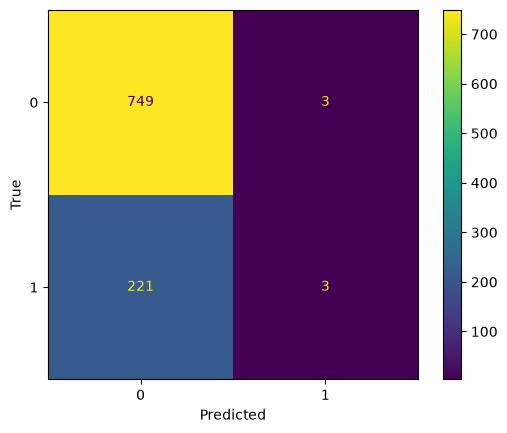

   accuracy         0.770
   precision        0.500
   recall           0.013
   f1               0.026
   roc_auc          0.657

there were 224 real returns in the test set


In [37]:
# ────────────────────────────────────────────────────────────────────
# 1) You need both hard predictions and predicted probabilities: the first four
#    metrics use the predictions, ROC AUC uses the probabilities.
# 2) Collect the five numbers into a dict or Series so you can reuse the same
#    function for every model you try today.
# 3) Draw the confusion matrix with the display helper, and label which axis is
#    truth and which is prediction.
# Search: "sklearn ConfusionMatrixDisplay from_estimator roc_auc_score"
# https://scikit-learn.org/stable/modules/model_evaluation.html
#
# ١) تحتاج التنبّؤات الصارمة والاحتمالات معًا: فالمقاييس الأربعة الأولى تستخدم
#    التنبّؤات، والمساحة تحت المنحنى تستخدم الاحتمالات.
# ٢) اجمع الأرقام الخمسة في قاموس أو Series لتتمكّن من إعادة استخدام الدالة
#    نفسها مع كل نموذج تجرّبه اليوم.
# ٣) ارسم مصفوفة الارتباك بأداة العرض، وبيّن أي محور للحقيقة وأيّهما
#    للتنبّؤ.
# ابحث عن: "sklearn ConfusionMatrixDisplay from_estimator roc_auc_score"
# ────────────────────────────────────────────────────────────────────

from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix,
                             f1_score, precision_score, roc_auc_score)
# TODO: Write an `evaluate` function returning accuracy, precision, recall, f1 and roc_auc for a fitted model on the test set.
# مهمة: اكتب دالة `evaluate` تُعيد الدقّة والدقّة الموجبة والاستدعاء وf1 والمساحة تحت المنحنى لنموذج مُلائَم على مجموعة الاختبار.
def evaluate(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    return {
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred),
        "recall": recall_score(y_eval, y_pred),
        "f1": f1_score(y_eval, y_pred),
        "roc_auc": roc_auc_score(y_eval, y_prob)
    }

baseline_scores = evaluate(baseline, X_test, y_test)
# TODO: Draw the confusion matrix for the baseline pipeline.
# مهمة: ارسم مصفوفة الارتباك لخط الأساس.
ConfusionMatrixDisplay.from_estimator(
    baseline,
    X_test,
    y_test
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
for key, value in baseline_scores.items():
    print(f"   {key:16s} {value:.3f}" if isinstance(value, float)
          else f"   {key:16s} {value}")
print(f"\nthere were {int(y_test.sum())} real returns in the test set")

**Stop and read what you just printed.**

The accuracy is close to the "always predict kept" number from Task 1.1 — and the recall is close
to zero. The model learned the cheapest way to be accurate: predict the majority class almost
every time.

That is why accuracy alone is insufficient on an imbalanced problem. It rewards a model for
ignoring exactly the thing you built it to find. **Write one sentence** here saying what you would
report to the shop instead of accuracy, and why.

*(I would report recall instead of accuracy because recall shows how many actual returns the model correctly identifies.)*

<div dir="rtl" align="right">

**توقّف واقرأ ما طبعته للتو.**

الدقّة قريبة من رقم «تنبّأ دائمًا بمحتفظ به» في المهمة ١٫١ — والاستدعاء قريب من الصفر. فقد تعلّم
النموذج أرخص طريقة ليكون دقيقًا: أن يتنبّأ بالفئة الأكبر في كل مرة تقريبًا.

ولهذا فالدقّة وحدها غير كافية في مسألة غير متوازنة. فهي تكافئ النموذج على تجاهل الشيء نفسه الذي
بنيته لإيجاده. **اكتب جملة واحدة** هنا تذكر فيها ما ستقدّمه للمتجر بدل الدقّة، ولماذا.

*(إجابتك.)*

</div>

### Task 2.3 — Make the model care about the minority class

There are two standard ways to stop a classifier ignoring the rare class:

1. **Class weights** — tell the model that getting a return wrong costs more than getting a kept
   order wrong. Nothing is added to the data; the loss function changes.
2. **SMOTE** — synthesise new minority-class examples so the training data itself is balanced.

Build both, and evaluate them the same way you evaluated the baseline.

**The rule that matters:** SMOTE must only ever see training data. If you resample before
splitting, synthetic rows built from test-set neighbours end up in your training set and your
score becomes fiction. Use the `imblearn` pipeline so the resampling step is part of the model and
is applied per fit, automatically.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — اجعل النموذج يهتم بالفئة الأقلية

هناك طريقتان قياسيتان لمنع المصنّف من تجاهل الفئة النادرة:

١. **أوزان الفئات** — أخبر النموذج أن الخطأ في حالة إرجاع يكلّف أكثر من الخطأ في طلب محتفظ به. ولا
   يُضاف شيء إلى البيانات، بل تتغيّر دالة الخسارة.
٢. **SMOTE** — تركيب أمثلة جديدة للفئة الأقلية حتى تتوازن بيانات التدريب نفسها.

ابنِ الاثنتين، وقيّمهما بالطريقة نفسها التي قيّمت بها خط الأساس.

**القاعدة المهمة:** يجب ألا يرى SMOTE إلا بيانات التدريب. فإن أعدت العيّنة قبل التقسيم، انتهت صفوف
اصطناعية مبنية من جيران مجموعة الاختبار داخل بيانات تدريبك وصارت نتيجتك خيالًا. استخدم خط معالجة
`imblearn` ليكون طور إعادة العيّنة جزءًا من النموذج ويُطبَّق مع كل ملاءمة تلقائيًّا.

</div>

In [38]:
# ────────────────────────────────────────────────────────────────────
# 1) The first model needs only one extra argument on the classifier — look for the
#    one that rebalances the loss automatically from the observed frequencies.
# 2) For SMOTE you need imblearn's Pipeline, not sklearn's: only the former knows
#    to resample during fit and to skip resampling during predict.
# 3) The order inside the SMOTE pipeline is preprocess, then resample, then classify.
#    SMOTE interpolates numerically, so it has to run after the encoding.
# 4) Fit both on the training data and evaluate both on the test data.
# Search: "imblearn Pipeline SMOTE class_weight balanced"
# https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html
#
# ١) يحتاج النموذج الأول وسيطًا إضافيًّا واحدًا على المصنّف — ابحث عن الوسيط الذي
#    يعيد موازنة الخسارة تلقائيًّا من التكرارات الملحوظة.
# ٢) يلزمك لـSMOTE خط معالجة imblearn لا sklearn: فالأول وحده يعرف أن يعيد العيّنة
#    أثناء الملاءمة وأن يتخطّاها أثناء التنبّؤ.
# ٣) الترتيب داخل خط SMOTE هو: معالجة مسبقة، ثم إعادة عيّنة، ثم تصنيف. فـSMOTE
#    يستوفي عدديًّا، لذا يجب أن يعمل بعد الترميز.
# ٤) لائِم الاثنين على بيانات التدريب وقيّمهما على بيانات الاختبار.
# ابحث عن: "imblearn Pipeline SMOTE class_weight balanced"
# ────────────────────────────────────────────────────────────────────

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
# TODO: Build a class-weighted pipeline and fit it.
# مهمة: ابنِ خط معالجة موزون الفئات ولائِمه.
# TODO: Build a SMOTE pipeline — preprocess, resample, classify — and fit it. The resampling must happen inside the pipeline so it only ever sees training rows.
# مهمة: ابنِ خط معالجة بـSMOTE — معالجة ثم إعادة عيّنة ثم تصنيف — ولائِمه. ويجب أن تقع إعادة العيّنة داخل خط المعالجة كي لا ترى إلا صفوف التدريب.
# TODO: Evaluate both and collect all three result rows into one table.
# مهمة: قيّم الاثنين واجمع صفوف النتائج الثلاثة في جدول واحد.
weighted = Pipeline([
    ("preprocessor", make_preprocessor(NUMERIC)),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        random_state=42
    ))
])

weighted.fit(X_train, y_train)

smote = ImbPipeline([
    ("preprocessor", make_preprocessor(NUMERIC)),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(random_state=42))
])

smote.fit(X_train, y_train)

weighted_scores = evaluate(weighted, X_test, y_test)
smote_scores = evaluate(smote, X_test, y_test)

comparison = pd.DataFrame([
    baseline_scores,
    weighted_scores,
    smote_scores
], index=["baseline", "class_weight", "SMOTE"])
print(comparison.to_string(float_format="{:.3f}".format))
print(f"\nreal returns in the test set: {int(y_test.sum())}")

              accuracy  precision  recall    f1  roc_auc
baseline         0.770      0.500   0.013 0.026    0.657
class_weight     0.598      0.312   0.625 0.417    0.658
SMOTE            0.594      0.308   0.616 0.411    0.655

real returns in the test set: 224


**Read the table as a trade, not as a leaderboard.**

Accuracy went *down* for both remedies. Recall went up enormously. The baseline was the most
accurate model in the table and the least useful one.

Which model you would ship depends on what a mistake costs: a missed return costs the shop
shipping and handling, while a false alarm costs whatever the intervention costs — an email, a
sturdier box, a delayed dispatch. **Write one or two sentences** naming which model you would
choose and what you would need to know about those two costs to defend the choice.

*(I would choose the class-weighted model because it improves recall significantly without creating synthetic samples. To defend this choice, I would need to know the cost of a missed return compared with the cost of a false alarm.)*

<div dir="rtl" align="right">

**اقرأ الجدول بوصفه مقايضة لا لوحة صدارة.**

انخفضت الدقّة في كلا العلاجين، وارتفع الاستدعاء ارتفاعًا هائلًا. فكان خط الأساس أدقّ نموذج في
الجدول وأقلّها فائدة.

ويتوقّف النموذج الذي ستشحنه على تكلفة الخطأ: فالإرجاع الفائت يكلّف المتجر الشحن والمناولة، أما
الإنذار الكاذب فيكلّف ما تكلّفه المعالجة — رسالة، أو صندوق أمتن، أو تأخير في الإرسال. **اكتب جملة
أو جملتين** تسمّي فيهما النموذج الذي ستختاره وما تحتاج معرفته عن هاتين التكلفتين للدفاع عن اختيارك.

*(إجابتك.)*

</div>

### Task 2.4 — Cross-validate, so the comparison survives a different split

Every number so far comes from one 80/20 split. On 4,880 rows the difference between two models
can easily be smaller than the difference between two random splits.

Cross-validate all three pipelines with stratified 5-fold, scoring both ROC AUC and recall, and
report the mean and standard deviation of each.

Because SMOTE lives inside its pipeline, `cross_validate` resamples **within each training fold**
automatically. That is the whole reason it was built that way — had you resampled the frame
beforehand, every fold's validation rows would be contaminated and these numbers would be
meaningless.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — تحقّق تقاطعيًّا لتصمد المقارنة أمام تقسيم مختلف

كل رقم حتى الآن يأتي من تقسيم واحد ٨٠/٢٠. وعلى ٤٨٨٠ صفًّا قد يكون الفرق بين نموذجين أصغر بسهولة من
الفرق بين تقسيمين عشوائيين.

تحقّق تقاطعيًّا من خطوط المعالجة الثلاثة بخمس طيّات طبقية، مع قياس المساحة تحت المنحنى والاستدعاء
معًا، واذكر المتوسّط والانحراف المعياري لكل منهما.

ولأن SMOTE يعيش داخل خط معالجته، فإن `cross_validate` يعيد العيّنة **داخل كل طيّة تدريب**
تلقائيًّا. وهذا هو سبب بنائه بهذه الطريقة — فلو أعدت العيّنة على الإطار مسبقًا لتلوّثت صفوف
التحقّق في كل طيّة ولأصبحت هذه الأرقام بلا معنى.

</div>

In [39]:
# ────────────────────────────────────────────────────────────────────
# 1) Use a stratified k-fold splitter so every fold keeps the 23% positive rate.
# 2) `cross_validate` accepts a list of scoring names and returns one array per
#    scorer — ask it for roc_auc and recall together rather than running it twice.
# 3) Report mean and standard deviation. A gap smaller than the standard deviation
#    is not a result you should claim.
# 4) Collect the rows into a DataFrame; you are saving it as an artefact shortly.
# Search: "sklearn cross_validate StratifiedKFold multiple scoring"
# https://scikit-learn.org/stable/modules/cross_validation.html
#
# ١) استخدم مقسّم طيّات طبقيًّا لتحتفظ كل طيّة بنسبة ٢٣٪ الموجبة.
# ٢) يقبل `cross_validate` قائمة بأسماء المقاييس ويعيد مصفوفة لكل مقياس — اطلب
#    منه roc_auc وrecall معًا بدل تشغيله مرتين.
# ٣) اذكر المتوسّط والانحراف المعياري. فالفارق الأصغر من الانحراف المعياري ليس
#    نتيجة تستطيع ادّعاءها.
# ٤) اجمع الصفوف في DataFrame؛ فستحفظه مخرجًا بعد قليل.
# ابحث عن: "sklearn cross_validate StratifiedKFold multiple scoring"
# ────────────────────────────────────────────────────────────────────

from sklearn.model_selection import StratifiedKFold, cross_validate
CANDIDATES = {"baseline": baseline, "class_weight": weighted, "SMOTE": smote}
# TODO: Cross-validate every candidate with stratified 5-fold on roc_auc and recall, collecting mean and standard deviation into one table.
# مهمة: تحقّق تقاطعيًّا من كل مرشّح بخمس طيّات طبقية على roc_auc وrecall، جامعًا المتوسّط والانحراف المعياري في جدول واحد.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rows = []

for name, model in CANDIDATES.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=["roc_auc", "recall"]
    )

    rows.append({
        "model": name,
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
        "recall_mean": scores["test_recall"].mean(),
        "recall_std": scores["test_recall"].std()
    })

cv_results = pd.DataFrame(rows).set_index("model")
print(cv_results.to_string(float_format="{:.3f}".format))

              roc_auc_mean  roc_auc_std  recall_mean  recall_std
model                                                           
baseline             0.646        0.021        0.017       0.003
class_weight         0.646        0.021        0.620       0.028
SMOTE                0.644        0.021        0.603       0.019


### Task 2.5 — The leakage demonstration

Now do the thing D3 told you not to. Add `refund_amount` to the numeric features, build the same
pipeline, fit it on the same training rows, and score it on the same test rows.

Everything about this model is identical to the baseline except one column.

<div dir="rtl" align="right">

### المهمة ٢٫٥ — برهان التسريب

افعل الآن ما نهاك عنه اليوم الثالث. أضف `refund_amount` إلى الخصائص الرقمية، وابنِ خط المعالجة
نفسه، ولائِمه على صفوف التدريب نفسها، وقيّمه على صفوف الاختبار نفسها.

وكل شيء في هذا النموذج مطابق لخط الأساس عدا عمود واحد.

</div>

In [40]:
# ────────────────────────────────────────────────────────────────────
# 1) Take the numeric list you loaded from the spec and add the leak column to a
#    copy of it. Do not mutate NUMERIC itself — you still need the honest list.
# 2) Build the same pipeline shape with that longer numeric list.
# 3) Fit on X_train plus the leak column and evaluate on X_test plus the leak
#    column, so the only difference from the baseline is the extra feature.
# Search: "sklearn pipeline add feature column"
#
# ١) خذ القائمة الرقمية التي حمّلتها من الملف وأضف عمود التسريب إلى نسخة منها.
#    ولا تغيّر NUMERIC نفسها — فما زلت تحتاج القائمة النزيهة.
# ٢) ابنِ الشكل نفسه من خط المعالجة بتلك القائمة الرقمية الأطول.
# ٣) لائِم على X_train مضافًا إليه عمود التسريب وقيّم على X_test مضافًا إليه
#    عمود التسريب، ليكون الفرق الوحيد عن خط الأساس هو الخاصية الزائدة.
# ابحث عن: "sklearn pipeline add feature column"
# ────────────────────────────────────────────────────────────────────

# TODO: Build and fit the same pipeline with the leaking column included, then score it on the same test rows.
# مهمة: ابنِ ولائِم خط المعالجة نفسه متضمّنًا العمود المُسرِّب، ثم قيّمه على صفوف الاختبار نفسها.
numeric_with_leak = NUMERIC + [LEAK]

X_train_leak = df.loc[X_train.index, FEATURES + [LEAK]]
X_test_leak = df.loc[X_test.index, FEATURES + [LEAK]]

leaked = Pipeline([
    ("preprocessor", make_preprocessor(numeric_with_leak)),
    ("classifier", LogisticRegression(random_state=42))
])

leaked.fit(X_train_leak, y_train)

leaked_scores = evaluate(leaked, X_test_leak, y_test)
leaked_scores["model"] = "leaked"
final = pd.concat([comparison, pd.DataFrame([leaked_scores]).set_index("model")])
print(final.to_string(float_format="{:.3f}".format))
print(f"\nAUC with the leak:    {leaked_scores['roc_auc']:.4f}")
print(f"AUC of the honest model: "
      f"{comparison.loc['class_weight', 'roc_auc']:.4f}")
print(f"the difference:          "
      f"{leaked_scores['roc_auc'] - comparison.loc['class_weight', 'roc_auc']:+.4f}")

              accuracy  precision  recall    f1  roc_auc
baseline         0.770      0.500   0.013 0.026    0.657
class_weight     0.598      0.312   0.625 0.417    0.658
SMOTE            0.594      0.308   0.616 0.411    0.655
leaked           0.960      1.000   0.826 0.905    0.994

AUC with the leak:    0.9942
AUC of the honest model: 0.6578
the difference:          +0.3364


**Why that number is worthless.**

The leaked model scores close to a perfect 1.0. If you saw that on a real project, the correct
reaction is not celebration — it is suspicion. Scores that good on a genuinely hard problem almost
always mean a column has told the model the answer.

Here is what would happen if you shipped it. The model is asked to score an order that is leaving
the warehouse right now. That order has not been returned, so no refund has been raised, so
`refund_amount` is 0 — exactly the value it has for every kept order in training. The model would
confidently predict "kept" for **every single order**, including all the ones about to come back.
A model with 0.999 AUC in your notebook would have zero recall in production.

**Write your own version** of that paragraph — in particular, say what value `refund_amount` holds
at prediction time and what the model would therefore predict.

*(At prediction time, refund_amount will be 0 because the order has not been returned or refunded yet. The model would therefore predict "kept" for every order, including orders that will later be returned.)*

<div dir="rtl" align="right">

**لماذا هذا الرقم بلا قيمة.**

يقترب النموذج المُسرَّب من الواحد الصحيح. ولو رأيت ذلك في مشروع حقيقي لكان ردّ الفعل الصحيح ليس
الاحتفال بل الريبة. فالنتائج بهذه الجودة في مسألة صعبة فعلًا تعني غالبًا أن عمودًا أخبر النموذج
بالإجابة.

وإليك ما سيحدث لو شحنته. يُطلب من النموذج تقييم طلب يغادر المستودع الآن. وهذا الطلب لم يُرجع، فلم
يُفتح له استرداد، فتكون قيمة `refund_amount` صفرًا — وهي القيمة نفسها التي تحملها كل الطلبات
المحتفظ بها في التدريب. فسيتنبّأ النموذج بثقة بـ«محتفظ به» لـ**كل طلب على الإطلاق**، بما فيها كل
الطلبات التي ستعود. فالنموذج ذو المساحة ٠٫٩٩٩ في دفترك سيكون استدعاؤه صفرًا في الإنتاج.

**اكتب صيغتك الخاصة** من تلك الفقرة — وبيّن تحديدًا ما القيمة التي يحملها `refund_amount` وقت
التنبّؤ وما الذي سيتنبّأ به النموذج بناءً عليها.

*(إجابتك.)*

</div>

## Section 3 — Stretch  (≈30 min)

Open-ended, and lower expectation of completeness.

`class_weight="balanced"` is one point on a curve, not the only choice. Every classifier that
produces probabilities lets you pick the threshold at which you call an order "at risk", and 0.5 is
just a default that nobody chose deliberately.

Sweep the threshold on your honest model's predicted probabilities and plot precision and recall
against it. Then pick the threshold you would actually deploy, and justify it with a cost: decide
what a missed return costs and what a false alarm costs, and choose the point that minimises the
total.

**Link to your capstone:** this is the difference between a model and a decision. Your report
should name the threshold you chose and the cost assumption behind it, not just quote an F1.

<div dir="rtl" align="right">

## القسم الثالث — الإضافي (نحو ٣٠ دقيقة)

قسم مفتوح، ولا يُتوقّع إكماله بالكامل.

`class_weight="balanced"` نقطة واحدة على منحنى لا الخيار الوحيد. فكل مصنّف يُنتج احتمالات يتيح لك
اختيار العتبة التي تسمّي عندها الطلب «معرّضًا للخطر»، و٠٫٥ مجرّد قيمة افتراضية لم يخترها أحد عمدًا.

امسح العتبة على احتمالات نموذجك النزيه وارسم الدقّة الموجبة والاستدعاء مقابلها. ثم اختر العتبة
التي ستنشرها فعلًا، وبرّرها بتكلفة: قرّر ما يكلّفه الإرجاع الفائت وما يكلّفه الإنذار الكاذب، واختر
النقطة التي تُصغّر المجموع.

**الصلة بمشروعك:** هذا هو الفرق بين النموذج والقرار. وينبغي أن يذكر تقريرك العتبة التي اخترتها
وافتراض التكلفة خلفها، لا أن يكتفي بذكر F1.

</div>

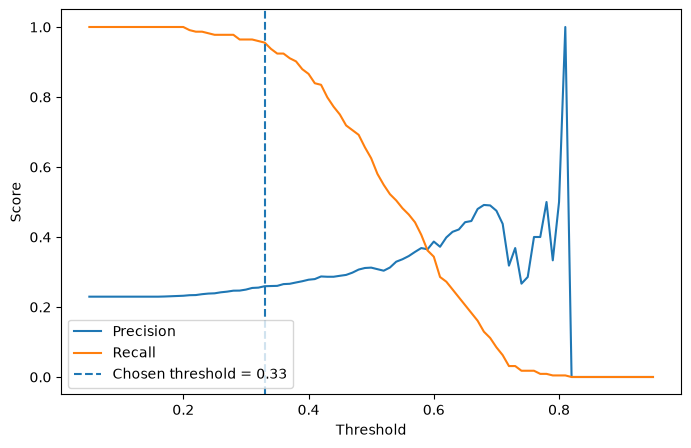

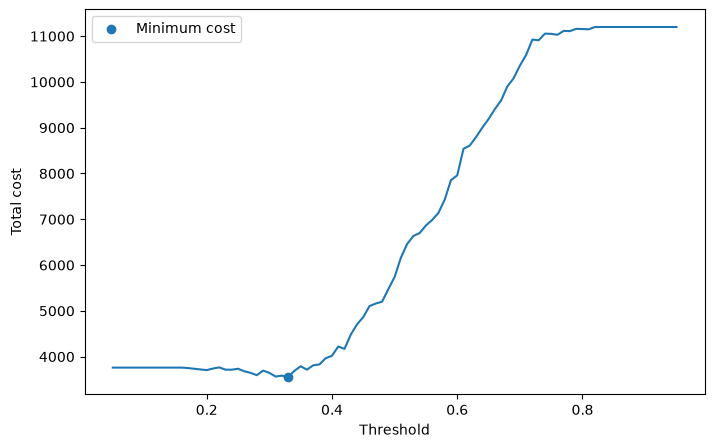

missed return cost: 50
false alarm cost: 5
chosen threshold: 0.33
minimum total cost: 3555


In [41]:
# ────────────────────────────────────────────────────────────────────
# Get the predicted probabilities from your honest model, sweep a range of
# thresholds, and compute precision and recall at each. Plot both against the
# threshold. Then define a cost per missed return and per false alarm, compute the
# total cost at each threshold, and mark the minimum on the chart.
#
# احصل على احتمالات نموذجك النزيه، وامسح مدى من العتبات، واحسب الدقّة الموجبة
# والاستدعاء عند كل عتبة. وارسم الاثنين مقابل العتبة. ثم عرّف تكلفة لكل إرجاع
# فائت ولكل إنذار كاذب، واحسب التكلفة الإجمالية عند كل عتبة، وعلّم الحد الأدنى
# على الرسم.
# ────────────────────────────────────────────────────────────────────

# TODO: Sweep the decision threshold, plot precision and recall, and pick one using an explicit cost assumption.
# مهمة: امسح عتبة القرار، وارسم الدقّة الموجبة والاستدعاء، واختر واحدة بافتراض تكلفة صريح.
y_prob = weighted.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)

precisions = []
recalls = []
costs = []

missed_return_cost = 50
false_alarm_cost = 5

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precisions.append(
        precision_score(y_test, y_pred_threshold, zero_division=0)
    )

    recalls.append(
        recall_score(y_test, y_pred_threshold, zero_division=0)
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred_threshold
    ).ravel()

    total_cost = (
        fn * missed_return_cost
        + fp * false_alarm_cost
    )

    costs.append(total_cost)

best_index = np.argmin(costs)
best_threshold = thresholds[best_index]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Chosen threshold = {best_threshold:.2f}"
)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(thresholds, costs)
plt.scatter(
    best_threshold,
    costs[best_index],
    label="Minimum cost"
)
plt.xlabel("Threshold")
plt.ylabel("Total cost")
plt.legend()
plt.show()

print(f"missed return cost: {missed_return_cost}")
print(f"false alarm cost: {false_alarm_cost}")
print(f"chosen threshold: {best_threshold:.2f}")
print(f"minimum total cost: {costs[best_index]}")

## Save your artefact

Save the honest pipeline and the cross-validation table. The pipeline is a complete model: it
carries its own scaler and encoder, so loading it and calling `predict` on a raw frame works
without you reconstructing anything.

Save the **honest** model. Saving the leaked one would be the single most expensive mistake in this
notebook.

<div dir="rtl" align="right">

## احفظ مخرجاتك

احفظ خط المعالجة النزيه وجدول التحقّق التقاطعي. وخط المعالجة نموذج كامل: فهو يحمل معايِره ومرمّزه
معه، فيعمل تحميله واستدعاء `predict` على إطار خام دون أن تعيد بناء أي شيء.

واحفظ النموذج **النزيه**. فحفظ المُسرَّب سيكون أغلى خطأ في هذا الدفتر.

</div>

In [42]:
# ────────────────────────────────────────────────────────────────────
# 1) Dump the honest pipeline with joblib into ARTEFACT_DIR.
# 2) Write the cross-validation table to parquet beside it.
# 3) Load the model straight back and predict on a couple of rows — an artefact you
#    have not reloaded is an artefact you have not tested.
# Search: "joblib dump load sklearn pipeline"
#
# ١) احفظ خط المعالجة النزيه بـjoblib في ARTEFACT_DIR.
# ٢) اكتب جدول التحقّق التقاطعي بصيغة parquet بجواره.
# ٣) أعد تحميل النموذج مباشرة وتنبّأ على صفّين — فالمخرج الذي لم تُعد تحميله مخرج
#    لم تختبره.
# ابحث عن: "joblib dump load sklearn pipeline"
# ────────────────────────────────────────────────────────────────────

# TODO: Save the honest pipeline and the CV results, then reload the model and predict on a few rows to prove the artefact works.
# مهمة: احفظ خط المعالجة النزيه ونتائج التحقّق التقاطعي، ثم أعد تحميل النموذج وتنبّأ على بضعة صفوف لإثبات أن المخرج يعمل.
model_path = ARTEFACT_DIR / "returns_pipeline.joblib"
cv_path = ARTEFACT_DIR / "returns_cv_results.parquet"

joblib.dump(weighted, model_path)
cv_results.to_parquet(cv_path)

reloaded_model = joblib.load(model_path)

sample_pred = reloaded_model.predict(X_test.head(5)).tolist()
print(f"saved {model_path.name} and {cv_path.name}")
print(f"reloaded model predicts on 5 rows: {sample_pred}")
print(f"actual:                            {y_test.head(5).tolist()}")

saved returns_pipeline.joblib and returns_cv_results.parquet
reloaded model predicts on 5 rows: [0, 0, 1, 0, 1]
actual:                            [0, 0, 0, 1, 0]


## Sanity check

Run this last. Every check that fails tells you what to fix and why.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخلية أخيرًا. كل فحص يفشل يخبرك بما يجب إصلاحه ولماذا.

</div>

In [43]:
# --- Sanity checks ----------------------------------------------------------------

check(LEAK not in FEATURES,
      f"{LEAK} must never be in the honest feature list",
      f"يجب ألا يكون {LEAK} في قائمة الخصائص النزيهة أبدًا")

check(abs(y_train.mean() - y_test.mean()) < 0.02,
      f"the split should preserve the class balance: train {y_train.mean():.1%} "
      f"vs test {y_test.mean():.1%}",
      f"يجب أن يحافظ التقسيم على توازن الفئات: تدريب {y_train.mean():.1%} "
      f"مقابل اختبار {y_test.mean():.1%}")

check(baseline_scores["recall"] < 0.20,
      f"the unweighted baseline should miss most returns, its recall is "
      f"{baseline_scores['recall']:.3f}",
      f"يجب أن يفوت خط الأساس غير الموزون معظم حالات الإرجاع، واستدعاؤه "
      f"{baseline_scores['recall']:.3f}")

check(comparison.loc["class_weight", "recall"] > baseline_scores["recall"] + 0.30,
      f"class weighting should raise recall a lot: "
      f"{baseline_scores['recall']:.3f} -> {comparison.loc['class_weight', 'recall']:.3f}",
      f"يجب أن ترفع أوزان الفئات الاستدعاء كثيرًا: "
      f"{baseline_scores['recall']:.3f} ← {comparison.loc['class_weight', 'recall']:.3f}")

check(comparison.loc["class_weight", "accuracy"] < baseline_scores["accuracy"],
      "the remedy should cost accuracy — that trade is the lesson; here it did not",
      "يجب أن يكلّف العلاج بعض الدقّة — فتلك المقايضة هي الدرس، ولم تحدث هنا")

check(0.55 < cv_results.loc["class_weight", "roc_auc_mean"] < 0.80,
      f"the honest problem should be hard but learnable, CV AUC is "
      f"{cv_results.loc['class_weight', 'roc_auc_mean']:.3f}",
      f"يجب أن تكون المسألة النزيهة صعبة لكن قابلة للتعلّم، والمساحة تحت المنحنى "
      f"{cv_results.loc['class_weight', 'roc_auc_mean']:.3f}")

check(leaked_scores["roc_auc"] > 0.95
      and leaked_scores["roc_auc"] - comparison.loc["class_weight", "roc_auc"] > 0.25,
      f"the leak should be dramatic: honest "
      f"{comparison.loc['class_weight', 'roc_auc']:.4f} vs leaked "
      f"{leaked_scores['roc_auc']:.4f}",
      f"يجب أن يكون التسريب صارخًا: النزيه "
      f"{comparison.loc['class_weight', 'roc_auc']:.4f} مقابل المُسرَّب "
      f"{leaked_scores['roc_auc']:.4f}")

check((ARTEFACT_DIR / "returns_pipeline.joblib").exists()
      and (ARTEFACT_DIR / "returns_cv_results.parquet").exists(),
      "both returns_pipeline.joblib and returns_cv_results.parquet should exist",
      "يجب أن يوجد الملفان returns_pipeline.joblib وreturns_cv_results.parquet")

report()

──────────────────────────────────────────────────────────────────
  ✓  refund_amount must never be in the honest feature list
  ✓  the split should preserve the class balance: train 23.0% vs test 23.0%
  ✓  the unweighted baseline should miss most returns, its recall is 0.013
  ✓  class weighting should raise recall a lot: 0.013 -> 0.625
  ✓  the remedy should cost accuracy — that trade is the lesson; here it did not
  ✓  the honest problem should be hard but learnable, CV AUC is 0.646
  ✓  the leak should be dramatic: honest 0.6578 vs leaked 0.9942
  ✓  both returns_pipeline.joblib and returns_cv_results.parquet should exist
──────────────────────────────────────────────────────────────────
  ✅ All 8 checks passed. / اجتزت جميع الفحوصات (8).
──────────────────────────────────────────────────────────────────


## What's next

That is Week 2. One dataset carried you from "what is even in this file" through cleaning and
feature engineering to a model you can defend — including the part where you proved your own best
score was a lie.

Take three things forward: **write down when each column becomes known** before you model anything;
**never report accuracy alone** on an imbalanced target; and **keep resampling inside the
pipeline**. All three will come up again in your capstone, and the leakage one will come up in
someone's demo.

<div dir="rtl" align="right">

## ماذا بعد

هذا هو الأسبوع الثاني. حملتك مجموعة بيانات واحدة من «ما الذي في هذا الملف أصلًا» عبر التنظيف
وهندسة الخصائص إلى نموذج تستطيع الدفاع عنه — بما في ذلك الجزء الذي أثبتّ فيه أن أفضل نتيجة لديك
كانت كذبة.

خذ معك ثلاثة أشياء: **دوّن متى تصبح كل قيمة معروفة** قبل أن تبني أي نموذج؛ و**لا تذكر الدقّة
وحدها** أبدًا على هدف غير متوازن؛ و**أبقِ إعادة العيّنة داخل خط المعالجة**. وستعود الثلاثة في
مشروع تخرّجك، وسيعود التسريب منها في عرض أحدهم.

</div>